# Tweets - NLP & Sentiment Analysis


In [2]:
# ============================================================
# IMPORTS
# ============================================================

import glob
import string

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import nltk

from gensim.models import Word2Vec

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.util import ngrams

from scipy.special import softmax

from sklearn.feature_extraction.text import (
    CountVectorizer,
    TfidfVectorizer
)

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    roc_auc_score
)

from sklearn.metrics.pairwise import cosine_similarity

from sklearn.model_selection import (
    GridSearchCV,
    train_test_split
)

from sklearn.naive_bayes import MultinomialNB

from sklearn.svm import LinearSVC

In [3]:
## CHARGEMENT + PREPROCESSING 18 DIFFERENT WAYS

def load_tweets(file_path, sentiment):
    with open(file_path, "r", encoding="utf-8") as file:
        content = file.read()

    tweets = [tweet.strip() for tweet in content.split(",") if tweet.strip()]

    df = pd.DataFrame({
        "tweet": tweets,
        "sentiment": sentiment
    })

    return df
negative = load_tweets("../Data/processedNegative.csv", "negative")
positive = load_tweets("../Data/processedPositive.csv", "positive")
neutral = load_tweets("../Data/processedNeutral.csv", "neutral")

# Shuffle the complete dataset
df = pd.concat([negative, positive, neutral], ignore_index=True)
# Mélanger les tweets
df = df.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

df.to_csv(
    "../Data/preprocessed_data/D1_Original.csv",
    index=False
)


## TEXT TO LOWER CASE ##
df_lowercase = df.copy()

df_lowercase["tweet"] = df_lowercase["tweet"].str.lower()
df_lowercase.to_csv(
    "../Data/preprocessed_data/D2_Lowercase.csv",
    index=False
)

## TEXT WITHOUT PONCTUATION ##
df_punctuation = df_lowercase.copy()

df_punctuation["tweet"] = df_punctuation["tweet"].apply(
    lambda text: text.translate(str.maketrans("", "", string.punctuation))
)
df_punctuation.to_csv(
    "../Data/preprocessed_data/D3_Lowercase_Punctuation.csv",
    index=False
)

## TEXT AVEC STOPWORD ( the , he , i , you , she)
nltk.download("stopwords")
stop_words = set(stopwords.words("english"))
df_stopwords = df_lowercase.copy()
df_stopwords["tweet"] = df_stopwords["tweet"].apply(
    lambda text: " ".join(
        word for word in text.split()
        if word not in stop_words
    )
)
df_stopwords.to_csv(
    "../Data/preprocessed_data/D4_Lowercase_Stopwords.csv",
    index=False
)

## TEXT STEMMING ( played ,  playing , is playing == play)
stemmer = PorterStemmer()
df_stemming = df_lowercase.copy()
df_stemming["tweet"] = df_stemming["tweet"].apply(
    lambda text: " ".join(
        stemmer.stem(word)
        for word in text.split()
    )
)
df_stemming.to_csv(
    "../Data/preprocessed_data/D5_Lowercase_Stemming.csv",
    index=False
)

## TEXT COMBINAISON ENTRE LES 3
df_stem_stopwords = df_lowercase.copy()

df_stem_stopwords["tweet"] = df_stem_stopwords["tweet"].apply(
    lambda text: " ".join(
        stemmer.stem(word)
        for word in text.split()
        if word not in stop_words
    )
)
df_stem_stopwords.to_csv(
    "../Data/preprocessed_data/D6_Lowercase_Stopwords_Stemming.csv",
    index=False
)

## TEXT COMBINAISON D3/D5
df_stem_punctuation = df_lowercase.copy()

df_stem_punctuation["tweet"] = df_stem_punctuation["tweet"].apply(
    lambda text: " ".join(
        stemmer.stem(word)
        for word in text.translate(
            str.maketrans("", "", string.punctuation)
        ).split()
    )
)
df_stem_punctuation.to_csv(
    "../Data/preprocessed_data/D7_Lowercase_Punctuation_Stemming.csv",
    index=False
)

## D8 — Lowercase + Punctuation + Stopwords
df_punct_stopwords = df_lowercase.copy()

df_punct_stopwords["tweet"] = df_punct_stopwords["tweet"].apply(
    lambda text: " ".join(
        word for word in text.translate(
            str.maketrans("", "", string.punctuation)
        ).split()
        if word not in stop_words
    )
)

df_punct_stopwords.to_csv(
    "../Data/preprocessed_data/D8_Lowercase_Punctuation_Stopwords.csv",
    index=False
)

## D9 — Lowercase + Punctuation + Stopwords + Stemming
df_all_stemming = df_lowercase.copy()

df_all_stemming["tweet"] = df_all_stemming["tweet"].apply(
    lambda text: " ".join(
        stemmer.stem(word)
        for word in text.translate(
            str.maketrans("", "", string.punctuation)
        ).split()
        if word not in stop_words
    )
)

df_all_stemming.to_csv(
    "../Data/preprocessed_data/D9_Lowercase_Punctuation_Stopwords_Stemming.csv",
    index=False
)

## D10 — Lowercase + Lemmatization
nltk.download("wordnet")
nltk.download("omw-1.4")
df_lemma = df_lowercase.copy()
lemmatizer = WordNetLemmatizer()

df_lemma["tweet"] = df_lemma["tweet"].apply(
    lambda text: " ".join(
        lemmatizer.lemmatize(word)
        for word in text.split()
    )
)

df_lemma.to_csv(
    "../Data/preprocessed_data/D10_Lowercase_Lemmatization.csv",
    index=False
)

## D11 — Lowercase + Stopwords + Lemmatization

df_lemma_stopwords = df_lowercase.copy()

df_lemma_stopwords["tweet"] = df_lemma_stopwords["tweet"].apply(
    lambda text: " ".join(
        lemmatizer.lemmatize(word)
        for word in text.split()
        if word not in stop_words
    )
)

df_lemma_stopwords.to_csv(
    "../Data/preprocessed_data/D11_Lowercase_Stopwords_Lemmatization.csv",
    index=False
)

## D12 — Lowercase + Punctuation + Lemmatization
df_lemma_punctuation = df_lowercase.copy()

df_lemma_punctuation["tweet"] = df_lemma_punctuation["tweet"].apply(
    lambda text: " ".join(
        lemmatizer.lemmatize(word)
        for word in text.translate(
            str.maketrans("", "", string.punctuation)
        ).split()
    )
)

df_lemma_punctuation.to_csv(
    "../Data/preprocessed_data/D12_Lowercase_Punctuation_Lemmatization.csv",
    index=False
)

## D13 — Lowercase + Punctuation + Stopwords + Lemmatization
df_all_lemma = df_lowercase.copy()

df_all_lemma["tweet"] = df_all_lemma["tweet"].apply(
    lambda text: " ".join(
        lemmatizer.lemmatize(word)
        for word in text.translate(
            str.maketrans("", "", string.punctuation)
        ).split()
        if word not in stop_words
    )
)

df_all_lemma.to_csv(
    "../Data/preprocessed_data/D13_Lowercase_Punctuation_Stopwords_Lemmatization.csv",
    index=False
)

## D14 — Lowercase + Bigram
df_bigram = df_lowercase.copy()

df_bigram["tweet"] = df_bigram["tweet"].apply(
    lambda text: " ".join(
        " ".join(pair)
        for pair in ngrams(text.split(), 2)
    )
)

df_bigram.to_csv(
    "../Data/preprocessed_data/D14_Lowercase_Bigram.csv",
    index=False
)

## D15 — Lowercase + Trigram
df_trigram = df_lowercase.copy()

df_trigram["tweet"] = df_trigram["tweet"].apply(
    lambda text: " ".join(
        " ".join(trigram)
        for trigram in ngrams(text.split(), 3)
    )
)

df_trigram.to_csv(
    "../Data/preprocessed_data/D15_Lowercase_Trigram.csv",
    index=False
)

## D16 — Lowercase + Stopwords + Bigram
df_stopwords_bigram = df_lowercase.copy()

df_stopwords_bigram["tweet"] = df_stopwords_bigram["tweet"].apply(
    lambda text: " ".join(
        " ".join(pair)
        for pair in ngrams(
            [word for word in text.split() if word not in stop_words],
            2
        )
    )
)

df_stopwords_bigram.to_csv(
    "../Data/preprocessed_data/D16_Lowercase_Stopwords_Bigram.csv",
    index=False
)

## D17 — Lowercase + Lemmatization + Bigram
df_lemma_bigram = df_lowercase.copy()

df_lemma_bigram["tweet"] = df_lemma_bigram["tweet"].apply(
    lambda text: " ".join(
        " ".join(pair)
        for pair in ngrams(
            [lemmatizer.lemmatize(word) for word in text.split()],
            2
        )
    )
)

df_lemma_bigram.to_csv(
    "../Data/preprocessed_data/D17_Lowercase_Lemmatization_Bigram.csv",
    index=False
)

## D18 — Lowercase + Stopwords + Lemmatization + Bigram
df_final_preprocess = df_lowercase.copy()

df_final_preprocess["tweet"] = df_final_preprocess["tweet"].apply(
    lambda text: " ".join(
        " ".join(pair)
        for pair in ngrams(
            [
                lemmatizer.lemmatize(word)
                for word in text.split()
                if word not in stop_words
            ],
            2
        )
    )
)

df_final_preprocess.to_csv(
    "../Data/preprocessed_data/D18_Lowercase_Stopwords_Lemmatization_Bigram.csv",
    index=False
)

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/lyamanichaimaa/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/lyamanichaimaa/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /Users/lyamanichaimaa/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [6]:
# ============================================================
# DATASET OVERVIEW
# ============================================================

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nDataset information:")
df.info()

print("\nMissing values:")
print(df.isnull().sum())

print("\nSentiment distribution:")
print(df["sentiment"].value_counts())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nFirst 5 tweets:")
display(df.head())

Dataset shape: (3865, 2)

Columns:
['tweet', 'sentiment']

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 3865 entries, 0 to 3864
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   tweet      3865 non-null   str  
 1   sentiment  3865 non-null   str  
dtypes: str(2)
memory usage: 60.5 KB

Missing values:
tweet        0
sentiment    0
dtype: int64

Sentiment distribution:
sentiment
neutral     1566
positive    1183
negative    1116
Name: count, dtype: int64

Duplicate rows: 413

First 5 tweets:


,tweet,sentiment
0,Paris,neutral
1,Thanks for connecting We are passionate about ...,positive
2,transferred in 1st major shuffle by,neutral
3,Share the love: thanks for being top new follo...,positive
4,just now I saw. But you did not reply unhappy,negative


In [7]:
# ============================================================
# COUNT BAG OF WORDS
# ============================================================

def vectorize_bow(file_path):
    data = pd.read_csv(file_path)

    X = data["tweet"].fillna("")
    y = data["sentiment"]

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.20,
        stratify=y,
        random_state=42
    )

    vectorizer = CountVectorizer()

    X_train_bow = vectorizer.fit_transform(X_train)
    X_test_bow = vectorizer.transform(X_test)

    return X_train_bow, X_test_bow, y_train, y_test, vectorizer


# Test avec D1
X_train_d1_bow, X_test_d1_bow, y_train_d1, y_test_d1, vectorizer_d1 = vectorize_bow(
    "../Data/preprocessed_data/D1_Original.csv"
)


# Vectorisation des 18 datasets
bow_results = {}

for i in range(1, 19):
    pattern = f"../Data/preprocessed_data/D{i}_*.csv"
    file_path = glob.glob(pattern)[0]

    bow_results[f"D{i}"] = vectorize_bow(file_path)

In [8]:
# ============================================================
# BINARY BAG OF WORDS
# ============================================================

def vectorize_binary(file_path):
    data = pd.read_csv(file_path)

    X = data["tweet"].fillna("")
    y = data["sentiment"]

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.20,
        stratify=y,
        random_state=42
    )

    vectorizer = CountVectorizer(binary=True)

    X_train_binary = vectorizer.fit_transform(X_train)
    X_test_binary = vectorizer.transform(X_test)

    return (
        X_train_binary,
        X_test_binary,
        y_train,
        y_test,
        vectorizer
    )


# Test avec D1
X_train_d1_binary, X_test_d1_binary, y_train_d1_binary, y_test_d1_binary, vectorizer_d1_binary = vectorize_binary(
    "../Data/preprocessed_data/D1_Original.csv"
)


# Vectorisation des 18 datasets
binary_results = {}

for i in range(1, 19):
    pattern = f"../Data/preprocessed_data/D{i}_*.csv"
    file_path = glob.glob(pattern)[0]

    binary_results[f"D{i}"] = vectorize_binary(file_path)

In [9]:
# ============================================================
# TF-IDF
# ============================================================

def vectorize_tfidf(file_path):
    data = pd.read_csv(file_path)

    X = data["tweet"].fillna("")
    y = data["sentiment"]

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.20,
        stratify=y,
        random_state=42
    )

    vectorizer = TfidfVectorizer()

    X_train_tfidf = vectorizer.fit_transform(X_train)
    X_test_tfidf = vectorizer.transform(X_test)

    return (
        X_train_tfidf,
        X_test_tfidf,
        y_train,
        y_test,
        vectorizer
    )


# Test avec D1
X_train_d1_tfidf, X_test_d1_tfidf, y_train_d1_tfidf, y_test_d1_tfidf, vectorizer_d1_tfidf = vectorize_tfidf(
    "../Data/preprocessed_data/D1_Original.csv"
)


# Vectorisation des 18 datasets
tfidf_results = {}

for i in range(1, 19):
    pattern = f"../Data/preprocessed_data/D{i}_*.csv"
    file_path = glob.glob(pattern)[0]

    tfidf_results[f"D{i}"] = vectorize_tfidf(file_path)

In [13]:
# ============================================================
# COSINE SIMILARITY
# ============================================================

# Create the same test set for each preprocessing dataset
# using stratified sampling.
test_texts = {}

for i in range(1, 19):
    pattern = f"../Data/preprocessed_data/D{i}_*.csv"
    file_path = glob.glob(pattern)[0]

    data = pd.read_csv(file_path)

    _, X_test, _, _ = train_test_split(
        data["tweet"].fillna(""),
        data["sentiment"],
        test_size=0.20,
        stratify=data["sentiment"],
        random_state=42
    )

    test_texts[f"D{i}"] = X_test.reset_index(drop=True)


def get_top_similar_pairs(X, texts, top_n=10):
    """
    Find the top-N most similar pairs of tweets.

    Exact duplicate vectors are ignored.
    Only the upper triangle of the similarity matrix is considered
    to avoid comparing each pair twice.
    """

    similarity_matrix = cosine_similarity(X)

    rows, cols = np.triu_indices_from(
        similarity_matrix,
        k=1
    )

    similarities = similarity_matrix[rows, cols]

    # Remove pairs with exactly identical vectors
    valid = similarities < 0.999999

    rows = rows[valid]
    cols = cols[valid]
    similarities = similarities[valid]

    if len(similarities) == 0:
        return pd.DataFrame(
            columns=["rank", "similarity", "tweet_1", "tweet_2"]
        )

    top_n = min(top_n, len(similarities))

    top_indices = np.argpartition(
        similarities,
        -top_n
    )[-top_n:]

    top_indices = top_indices[
        np.argsort(similarities[top_indices])[::-1]
    ]

    results = []

    for rank, idx in enumerate(top_indices, start=1):
        results.append({
            "rank": rank,
            "similarity": similarities[idx],
            "tweet_1": texts.iloc[rows[idx]],
            "tweet_2": texts.iloc[cols[idx]]
        })

    return pd.DataFrame(results)


def analyze_dataset(dataset_name):
    """
    Compute the top-10 similar tweet pairs for
    Count BOW, Binary BOW and TF-IDF.
    """

    count_data = bow_results[dataset_name]
    binary_data = binary_results[dataset_name]
    tfidf_data = tfidf_results[dataset_name]

    texts = test_texts[dataset_name]

    results = {
        "Count": get_top_similar_pairs(
            count_data[1],
            texts
        ),
        "Binary": get_top_similar_pairs(
            binary_data[1],
            texts
        ),
        "TF-IDF": get_top_similar_pairs(
            tfidf_data[1],
            texts
        )
    }

    return results


# Compute similarity results for all 18 datasets
similarity_results = {}

for i in range(1, 19):
    dataset_name = f"D{i}"
    similarity_results[dataset_name] = analyze_dataset(dataset_name)

In [16]:
# ============================================================
# LOGISTIC REGRESSION
# ============================================================

def train_logistic_regression(X_train, X_test, y_train, y_test):
    model = LogisticRegression(
        max_iter=1000,
        random_state=42
    )

    param_grid = {
        "C": [0.01, 0.1, 1, 10, 100]
    }

    grid_search = GridSearchCV(
        model,
        param_grid,
        cv=5,
        scoring="accuracy",
        n_jobs=-1
    )

    grid_search.fit(X_train, y_train)

    best_model = grid_search.best_estimator_

    y_pred = best_model.predict(X_test)
    y_proba = best_model.predict_proba(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    auc = roc_auc_score(
        y_test,
        y_proba,
        multi_class="ovr"
    )

    macro_f1 = f1_score(
        y_test,
        y_pred,
        average="macro"
    )

    return {
        "model": best_model,
        "best_C": grid_search.best_params_["C"],
        "cv_score": grid_search.best_score_,
        "accuracy": accuracy,
        "auc": auc,
        "macro_f1": macro_f1,
        "y_pred": y_pred,
        "y_proba": y_proba
    }


logistic_results = []

for dataset_name in bow_results:

    vectorizations = {
        "Count": bow_results[dataset_name],
        "Binary": binary_results[dataset_name],
        "TF-IDF": tfidf_results[dataset_name]
    }

    for vectorization_name, data in vectorizations.items():

        X_train, X_test, y_train, y_test, vectorizer = data

        result = train_logistic_regression(
            X_train,
            X_test,
            y_train,
            y_test
        )

        result.update({
            "dataset": dataset_name,
            "vectorization": vectorization_name
        })

        logistic_results.append(result)


logistic_results_df = pd.DataFrame(logistic_results)

logistic_results_df = logistic_results_df[
    [
        "dataset",
        "vectorization",
        "best_C",
        "cv_score",
        "accuracy",
        "auc",
        "macro_f1",
        "model",
        "y_pred",
        "y_proba"
    ]
]


In [17]:
logistic_results_df.sort_values(
    "accuracy",
    ascending=False
).head(5)[
    [
        "dataset",
        "vectorization",
        "best_C",
        "cv_score",
        "accuracy",
        "auc",
        "macro_f1"
    ]
]

,dataset,vectorization,best_C,cv_score,accuracy,auc,macro_f1
4,D2,Binary,1.0,0.882275,0.909444,0.978937,0.907302
1,D1,Binary,1.0,0.882275,0.909444,0.978937,0.907302
27,D10,Count,1.0,0.876452,0.905563,0.977510,0.903687
49,D17,Binary,1.0,0.875156,0.905563,0.977805,0.903470
33,D12,Count,1.0,0.880332,0.905563,0.976818,0.903653


In [20]:
# ============================================================
# LOGISTIC REGRESSION RESULTS
# ============================================================

# Select the best Logistic Regression experiment
best_logistic = logistic_results_df.loc[
    logistic_results_df["accuracy"].idxmax()
]

best_dataset_logistic = best_logistic["dataset"]
best_vectorization_logistic = best_logistic["vectorization"]

# Retrieve the corresponding test data
if best_vectorization_logistic == "Count":
    best_data_logistic = bow_results[best_dataset_logistic]
elif best_vectorization_logistic == "Binary":
    best_data_logistic = binary_results[best_dataset_logistic]
else:
    best_data_logistic = tfidf_results[best_dataset_logistic]

X_train_logistic, X_test_logistic, y_train_logistic, y_test_logistic, vectorizer_logistic = best_data_logistic

# Best trained model
best_model_logistic = best_logistic["model"]

# Predictions
y_pred_logistic = best_model_logistic.predict(X_test_logistic)
y_proba_logistic = best_model_logistic.predict_proba(X_test_logistic)

print("Best Logistic Regression configuration:")
print(f"Dataset: {best_dataset_logistic}")
print(f"Vectorization: {best_vectorization_logistic}")
print(f"Best C: {best_logistic['best_C']}")
print(f"CV Score: {best_logistic['cv_score']:.6f}")
print(f"Accuracy: {best_logistic['accuracy']:.6f}")
print(f"AUC: {best_logistic['auc']:.6f}")
print(f"Macro F1: {best_logistic['macro_f1']:.6f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test_logistic,
        y_pred_logistic
    )
)

Best Logistic Regression configuration:
Dataset: D1
Vectorization: Binary
Best C: 1.0
CV Score: 0.882275
Accuracy: 0.909444
AUC: 0.978937
Macro F1: 0.907302

Classification Report:
              precision    recall  f1-score   support

    negative       0.93      0.89      0.91       223
     neutral       0.88      0.97      0.92       313
    positive       0.93      0.85      0.89       237

    accuracy                           0.91       773
   macro avg       0.91      0.90      0.91       773
weighted avg       0.91      0.91      0.91       773



In [41]:
# ============================================================
# LINEAR SVM
# ============================================================

def train_svm(X_train, X_test, y_train, y_test):
    model = LinearSVC(
        max_iter=20000,
        dual="auto",
        random_state=42
    )

    param_grid = {
        "C": [0.01, 0.1, 1, 10, 100]
    }

    grid_search = GridSearchCV(
        model,
        param_grid,
        cv=5,
        scoring="accuracy",
        n_jobs=-1
    )

    grid_search.fit(X_train, y_train)

    best_model = grid_search.best_estimator_

    y_pred = best_model.predict(X_test)

    # LinearSVC does not provide predict_proba().
    # We convert decision scores to normalized probabilities
    # for multiclass ROC-AUC calculation.
    y_scores = best_model.decision_function(X_test)
    y_proba = softmax(y_scores, axis=1)

    accuracy = accuracy_score(y_test, y_pred)

    auc = roc_auc_score(
        y_test,
        y_proba,
        multi_class="ovr"
    )

    macro_f1 = f1_score(
        y_test,
        y_pred,
        average="macro"
    )

    return {
        "model": best_model,
        "best_C": grid_search.best_params_["C"],
        "cv_score": grid_search.best_score_,
        "accuracy": accuracy,
        "auc": auc,
        "macro_f1": macro_f1,
        "y_pred": y_pred,
        "y_proba": y_proba
    }


svm_results = []

for dataset_name in bow_results:

    vectorizations = {
        "Count": bow_results[dataset_name],
        "Binary": binary_results[dataset_name],
        "TF-IDF": tfidf_results[dataset_name]
    }

    for vectorization_name, data in vectorizations.items():

        X_train, X_test, y_train, y_test, vectorizer = data

        result = train_svm(
            X_train,
            X_test,
            y_train,
            y_test
        )

        result.update({
            "dataset": dataset_name,
            "vectorization": vectorization_name
        })

        svm_results.append(result)


svm_results_df = pd.DataFrame(svm_results)

svm_results_df = svm_results_df[
    [
        "dataset",
        "vectorization",
        "best_C",
        "cv_score",
        "accuracy",
        "auc",
        "macro_f1",
        "model",
        "y_pred",
        "y_proba"
    ]
]

/Users/lyamanichaimaa/Desktop/SLOT SYSTEM/PROJECTS/Tweets/venv/lib/python3.13/site-packages/sklearn/svm/_base.py:1298: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/lyamanichaimaa/Desktop/SLOT SYSTEM/PROJECTS/Tweets/venv/lib/python3.13/site-packages/sklearn/svm/_base.py:1298: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/lyamanichaimaa/Desktop/SLOT SYSTEM/PROJECTS/Tweets/venv/lib/python3.13/site-packages/sklearn/svm/_base.py:1298: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/lyamanichaimaa/Desktop/SLOT SYSTEM/PROJECTS/Tweets/venv/lib/python3.13/site-packages/sklearn/svm/_base.py:1298: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/lyamanichaimaa/Desktop/SLOT SYSTEM/PROJECTS/Tweets/venv/lib/python3.13/site-packages/sklearn/svm/_base.py:129

In [24]:
# ============================================================
# LINEAR SVM RESULTS
# ============================================================

# Select the best SVM experiment
best_svm = svm_results_df.loc[
    svm_results_df["accuracy"].idxmax()
]

best_dataset_svm = best_svm["dataset"]
best_vectorization_svm = best_svm["vectorization"]

# Retrieve the corresponding test data
if best_vectorization_svm == "Count":
    best_data_svm = bow_results[best_dataset_svm]
elif best_vectorization_svm == "Binary":
    best_data_svm = binary_results[best_dataset_svm]
else:
    best_data_svm = tfidf_results[best_dataset_svm]

X_train_svm, X_test_svm, y_train_svm, y_test_svm, vectorizer_svm = best_data_svm

# Best trained model
best_model_svm = best_svm["model"]

# Predictions
y_pred_svm = best_model_svm.predict(X_test_svm)

y_scores_svm = best_model_svm.decision_function(X_test_svm)
y_proba_svm = softmax(y_scores_svm, axis=1)

print("Best Linear SVM configuration:")
print(f"Dataset: {best_dataset_svm}")
print(f"Vectorization: {best_vectorization_svm}")
print(f"Best C: {best_svm['best_C']}")
print(f"CV Score: {best_svm['cv_score']:.6f}")
print(f"Accuracy: {best_svm['accuracy']:.6f}")
print(f"AUC: {best_svm['auc']:.6f}")
print(f"Macro F1: {best_svm['macro_f1']:.6f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test_svm,
        y_pred_svm
    )
)

Best Linear SVM configuration:
Dataset: D10
Vectorization: Binary
Best C: 0.1
CV Score: 0.876129
Accuracy: 0.906856
AUC: 0.978091
Macro F1: 0.905396

Classification Report:
              precision    recall  f1-score   support

    negative       0.95      0.88      0.91       223
     neutral       0.86      0.98      0.92       313
    positive       0.94      0.84      0.89       237

    accuracy                           0.91       773
   macro avg       0.92      0.90      0.91       773
weighted avg       0.91      0.91      0.91       773



In [40]:
# ============================================================
# MULTINOMIAL NAIVE BAYES
# ============================================================

def train_naive_bayes(X_train, X_test, y_train, y_test):
    model = MultinomialNB()

    param_grid = {
        "alpha": [0.01, 0.1, 0.5, 1.0, 2.0]
    }

    grid_search = GridSearchCV(
        model,
        param_grid,
        cv=5,
        scoring="accuracy",
        n_jobs=-1
    )

    grid_search.fit(X_train, y_train)

    best_model = grid_search.best_estimator_

    y_pred = best_model.predict(X_test)
    y_proba = best_model.predict_proba(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    auc = roc_auc_score(
        y_test,
        y_proba,
        multi_class="ovr"
    )

    macro_f1 = f1_score(
        y_test,
        y_pred,
        average="macro"
    )

    return {
        "model": best_model,
        "best_alpha": grid_search.best_params_["alpha"],
        "cv_score": grid_search.best_score_,
        "accuracy": accuracy,
        "auc": auc,
        "macro_f1": macro_f1,
        "y_pred": y_pred,
        "y_proba": y_proba
    }


nb_results = []

for dataset_name in bow_results:

    vectorizations = {
        "Count": bow_results[dataset_name],
        "Binary": binary_results[dataset_name],
        "TF-IDF": tfidf_results[dataset_name]
    }

    for vectorization_name, data in vectorizations.items():

        X_train, X_test, y_train, y_test, vectorizer = data

        result = train_naive_bayes(
            X_train,
            X_test,
            y_train,
            y_test
        )

        result.update({
            "dataset": dataset_name,
            "vectorization": vectorization_name
        })

        nb_results.append(result)


nb_results_df = pd.DataFrame(nb_results)

nb_results_df = nb_results_df[
    [
        "dataset",
        "vectorization",
        "best_alpha",
        "cv_score",
        "accuracy",
        "auc",
        "macro_f1",
        "model",
        "y_pred",
        "y_proba"
    ]
]

In [27]:
nb_results_df.sort_values(
    "accuracy",
    ascending=False
).head(5)[
    [
        "dataset",
        "vectorization",
        "best_alpha",
        "cv_score",
        "accuracy",
        "auc",
        "macro_f1"
    ]
]

,dataset,vectorization,best_alpha,cv_score,accuracy,auc,macro_f1
23,D8,TF-IDF,2.0,0.868052,0.895213,0.975582,0.891044
11,D4,TF-IDF,2.0,0.869345,0.893920,0.973841,0.890255
17,D6,TF-IDF,2.0,0.857051,0.893920,0.971193,0.890156
14,D5,TF-IDF,2.0,0.862230,0.892626,0.968573,0.889141
29,D10,TF-IDF,2.0,0.867726,0.892626,0.968291,0.889093


In [28]:
# ============================================================
# NAIVE BAYES RESULTS
# ============================================================

# Select the best Naive Bayes experiment
best_nb = nb_results_df.loc[
    nb_results_df["accuracy"].idxmax()
]

best_dataset_nb = best_nb["dataset"]
best_vectorization_nb = best_nb["vectorization"]

# Retrieve the corresponding test data
if best_vectorization_nb == "Count":
    best_data_nb = bow_results[best_dataset_nb]
elif best_vectorization_nb == "Binary":
    best_data_nb = binary_results[best_dataset_nb]
else:
    best_data_nb = tfidf_results[best_dataset_nb]

X_train_nb, X_test_nb, y_train_nb, y_test_nb, vectorizer_nb = best_data_nb

# Best trained model
best_model_nb = best_nb["model"]

# Predictions
y_pred_nb = best_model_nb.predict(X_test_nb)
y_proba_nb = best_model_nb.predict_proba(X_test_nb)

print("Best Naive Bayes configuration:")
print(f"Dataset: {best_dataset_nb}")
print(f"Vectorization: {best_vectorization_nb}")
print(f"Best alpha: {best_nb['best_alpha']}")
print(f"CV Score: {best_nb['cv_score']:.6f}")
print(f"Accuracy: {best_nb['accuracy']:.6f}")
print(f"AUC: {best_nb['auc']:.6f}")
print(f"Macro F1: {best_nb['macro_f1']:.6f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test_nb,
        y_pred_nb
    )
)

Best Naive Bayes configuration:
Dataset: D8
Vectorization: TF-IDF
Best alpha: 2.0
CV Score: 0.868052
Accuracy: 0.895213
AUC: 0.975582
Macro F1: 0.891044

Classification Report:
              precision    recall  f1-score   support

    negative       0.87      0.90      0.88       223
     neutral       0.92      0.94      0.93       313
    positive       0.90      0.84      0.86       237

    accuracy                           0.90       773
   macro avg       0.89      0.89      0.89       773
weighted avg       0.90      0.90      0.89       773



In [31]:
# ============================================================
# FINAL MODEL COMPARISON
# ============================================================

final_comparison = pd.DataFrame([
    {
        "Algorithm": "Logistic Regression",
        "Dataset": best_dataset_logistic,
        "Vectorization": best_vectorization_logistic,
        "Hyperparameter": f"C = {best_logistic['best_C']}",
        "CV Score": best_logistic["cv_score"],
        "Accuracy": best_logistic["accuracy"],
        "AUC": best_logistic["auc"],
        "Macro F1": best_logistic["macro_f1"]
    },
    {
        "Algorithm": "Linear SVM",
        "Dataset": best_dataset_svm,
        "Vectorization": best_vectorization_svm,
        "Hyperparameter": f"C = {best_svm['best_C']}",
        "CV Score": best_svm["cv_score"],
        "Accuracy": best_svm["accuracy"],
        "AUC": best_svm["auc"],
        "Macro F1": best_svm["macro_f1"]
    },
    {
        "Algorithm": "Naive Bayes",
        "Dataset": best_dataset_nb,
        "Vectorization": best_vectorization_nb,
        "Hyperparameter": f"alpha = {best_nb['best_alpha']}",
        "CV Score": best_nb["cv_score"],
        "Accuracy": best_nb["accuracy"],
        "AUC": best_nb["auc"],
        "Macro F1": best_nb["macro_f1"]
    }
])

final_comparison

,Algorithm,Dataset,Vectorization,Hyperparameter,CV Score,Accuracy,AUC,Macro F1
0,Logistic Regression,D1,Binary,C = 1.0,0.882275,0.909444,0.978937,0.907302
1,Linear SVM,D10,Binary,C = 0.1,0.876129,0.906856,0.978091,0.905396
2,Naive Bayes,D8,TF-IDF,alpha = 2.0,0.868052,0.895213,0.975582,0.891044


In [33]:
# ============================================================
# F1-SCORE COMPARISON
# ============================================================

labels = ["negative", "neutral", "positive"]

f1_comparison = pd.DataFrame({
    "Logistic Regression": f1_score(
        y_test_logistic,
        y_pred_logistic,
        labels=labels,
        average=None
    ),
    "Linear SVM": f1_score(
        y_test_svm,
        y_pred_svm,
        labels=labels,
        average=None
    ),
    "Naive Bayes": f1_score(
        y_test_nb,
        y_pred_nb,
        labels=labels,
        average=None
    )
}, index=["Negative", "Neutral", "Positive"])

f1_comparison

,Logistic Regression,Linear SVM,Naive Bayes
Negative,0.908257,0.911628,0.881057
Neutral,0.923780,0.916168,0.927445
Positive,0.889868,0.888393,0.864629


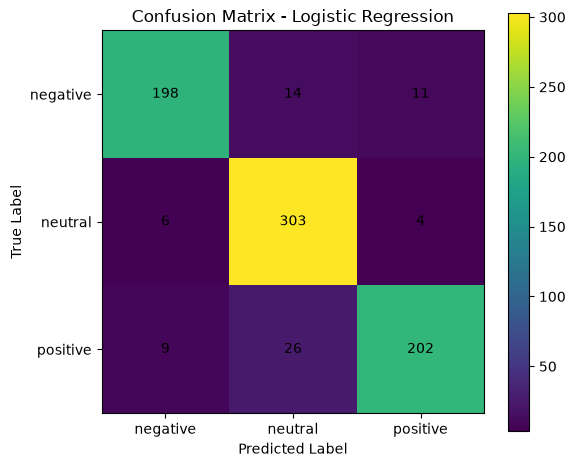

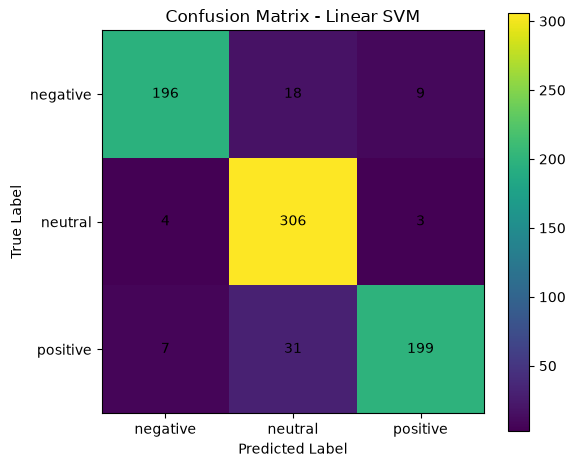

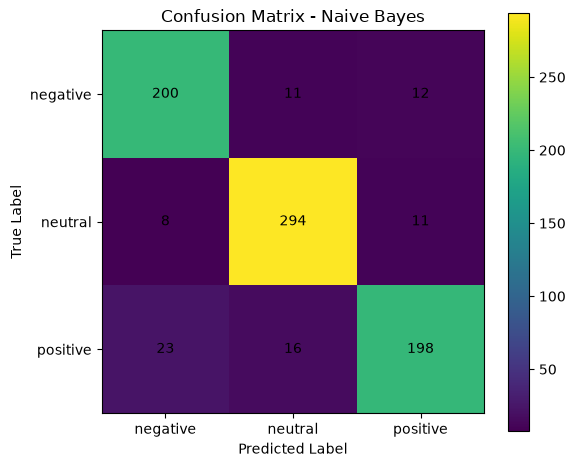

In [34]:
# ============================================================
# CONFUSION MATRICES
# ============================================================

models = {
    "Logistic Regression": (y_test_logistic, y_pred_logistic),
    "Linear SVM": (y_test_svm, y_pred_svm),
    "Naive Bayes": (y_test_nb, y_pred_nb)
}

labels = ["negative", "neutral", "positive"]

for model_name, (y_test, y_pred) in models.items():

    cm = confusion_matrix(
        y_test,
        y_pred,
        labels=labels
    )

    plt.figure(figsize=(6, 5))

    plt.imshow(cm)

    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")

    plt.xticks(
        range(len(labels)),
        labels
    )

    plt.yticks(
        range(len(labels)),
        labels
    )

    for i in range(len(labels)):
        for j in range(len(labels)):
            plt.text(
                j,
                i,
                cm[i, j],
                ha="center",
                va="center"
            )

    plt.colorbar()
    plt.tight_layout()
    plt.show()

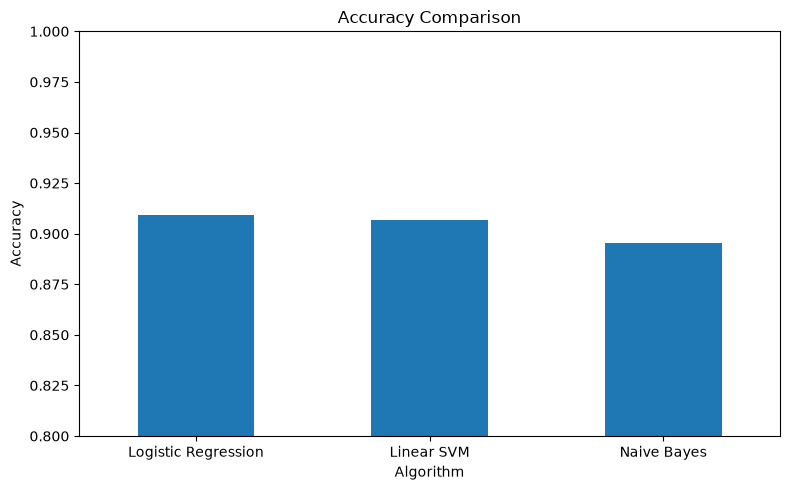

In [35]:
# ============================================================
# ACCURACY COMPARISON
# ============================================================

accuracy_comparison = final_comparison.set_index("Algorithm")["Accuracy"]

plt.figure(figsize=(8, 5))

accuracy_comparison.plot(
    kind="bar"
)

plt.title("Accuracy Comparison")
plt.xlabel("Algorithm")
plt.ylabel("Accuracy")
plt.ylim(0.8, 1.0)

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

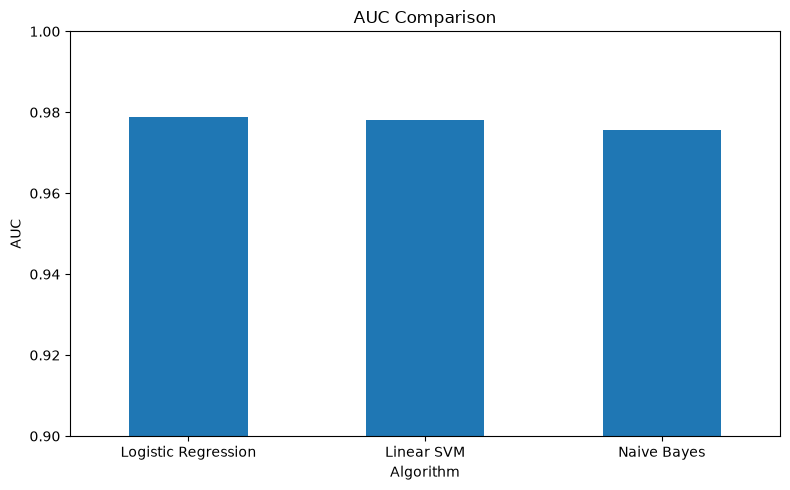

In [36]:
# ============================================================
# AUC COMPARISON
# ============================================================

auc_comparison = final_comparison.set_index("Algorithm")["AUC"]

plt.figure(figsize=(8, 5))

auc_comparison.plot(
    kind="bar"
)

plt.title("AUC Comparison")
plt.xlabel("Algorithm")
plt.ylabel("AUC")
plt.ylim(0.9, 1.0)

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

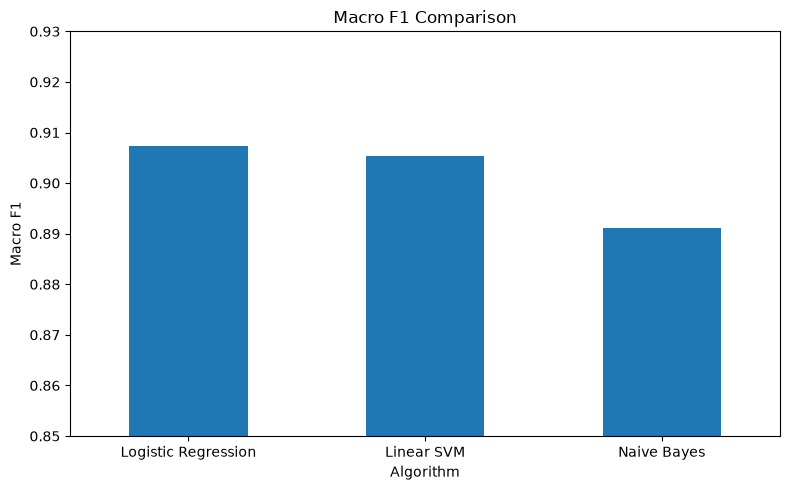

In [37]:
# ============================================================
# MACRO F1 COMPARISON
# ============================================================

f1_comparison = final_comparison.set_index("Algorithm")["Macro F1"]

plt.figure(figsize=(8, 5))

f1_comparison.plot(
    kind="bar"
)

plt.title("Macro F1 Comparison")
plt.xlabel("Algorithm")
plt.ylabel("Macro F1")
plt.ylim(0.85, 0.93)

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [39]:
# ============================================================
# BONUS — WORD2VEC
# ============================================================

from gensim.models import Word2Vec
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    roc_auc_score,
    f1_score
)


# ============================================================
# 1. CHARGER D1
# ============================================================

d1_path = "../Data/preprocessed_data/D1_Original.csv"

df_w2v = pd.read_csv(d1_path)

print("Dataset utilisé : D1")
print("Nombre de tweets :", len(df_w2v))
print()


# ============================================================
# 2. PREPARER LES TWEETS
# ============================================================

sentences = (
    df_w2v["tweet"]
    .fillna("")
    .astype(str)
    .apply(str.split)
    .tolist()
)


# ============================================================
# 3. SEPARER TRAIN / TEST
# ============================================================

X_text_train, X_text_test, y_train_w2v, y_test_w2v = train_test_split(
    df_w2v["tweet"],
    df_w2v["sentiment"],
    test_size=0.20,
    random_state=42,
    stratify=df_w2v["sentiment"]
)


print("Train :", len(X_text_train))
print("Test  :", len(X_text_test))
print()


# ============================================================
# 4. ENTRAINER WORD2VEC SUR LE TRAIN UNIQUEMENT
# ============================================================

train_sentences = (
    X_text_train
    .fillna("")
    .astype(str)
    .apply(str.split)
    .tolist()
)


word2vec_model = Word2Vec(
    sentences=train_sentences,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
    sg=1,
    seed=42
)


print("Word2Vec entraîné avec succès.")
print("Taille du vocabulaire :", len(word2vec_model.wv))
print()


# ============================================================
# 5. TRANSFORMER UN TWEET EN VECTEUR
# ============================================================

def tweet_to_vector(tweet, model):

    words = tweet.split()

    vectors = [
        model.wv[word]
        for word in words
        if word in model.wv
    ]

    if len(vectors) == 0:
        return np.zeros(model.vector_size)

    return np.mean(vectors, axis=0)


# ============================================================
# 6. TRANSFORMER TRAIN ET TEST EN VECTEURS WORD2VEC
# ============================================================

X_train_w2v = np.array([
    tweet_to_vector(tweet, word2vec_model)
    for tweet in X_text_train
])

X_test_w2v = np.array([
    tweet_to_vector(tweet, word2vec_model)
    for tweet in X_text_test
])


print("Word2Vec representations:")
print("X_train :", X_train_w2v.shape)
print("X_test  :", X_test_w2v.shape)
print()


# ============================================================
# 7. LOGISTIC REGRESSION + GRIDSEARCH
# ============================================================

param_grid_w2v = {
    "C": [0.01, 0.1, 1, 10, 100]
}


logistic_w2v = LogisticRegression(
    max_iter=2000,
    random_state=42
)


grid_w2v = GridSearchCV(
    estimator=logistic_w2v,
    param_grid=param_grid_w2v,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)


grid_w2v.fit(
    X_train_w2v,
    y_train_w2v
)


# ============================================================
# 8. PREDICTIONS
# ============================================================

best_w2v_model = grid_w2v.best_estimator_

y_pred_w2v = best_w2v_model.predict(X_test_w2v)

y_proba_w2v = best_w2v_model.predict_proba(X_test_w2v)


# ============================================================
# 9. METRICS
# ============================================================

accuracy_w2v = accuracy_score(
    y_test_w2v,
    y_pred_w2v
)


auc_w2v = roc_auc_score(
    y_test_w2v,
    y_proba_w2v,
    multi_class="ovr",
    average="weighted"
)


macro_f1_w2v = f1_score(
    y_test_w2v,
    y_pred_w2v,
    average="macro"
)


# ============================================================
# 10. AFFICHER LES RESULTATS
# ============================================================

print("=" * 60)
print("WORD2VEC + LOGISTIC REGRESSION")
print("=" * 60)

print(
    "Best C :",
    grid_w2v.best_params_["C"]
)

print(
    "Best CV Score :",
    round(grid_w2v.best_score_, 6)
)

print(
    "Test Accuracy :",
    round(accuracy_w2v, 6)
)

print(
    "Test AUC :",
    round(auc_w2v, 6)
)

print(
    "Macro F1 :",
    round(macro_f1_w2v, 6)
)


print("\nClassification Report:")

print(
    classification_report(
        y_test_w2v,
        y_pred_w2v
    )
)


# ============================================================
# 11. RESULTAT FINAL WORD2VEC
# ============================================================

word2vec_results = pd.DataFrame([{
    "dataset": "D1",
    "vectorization": "Word2Vec",
    "model": "Logistic Regression",
    "best_C": grid_w2v.best_params_["C"],
    "cv_score": grid_w2v.best_score_,
    "accuracy": accuracy_w2v,
    "auc": auc_w2v,
    "macro_f1": macro_f1_w2v
}])


print("\nWord2Vec Results:")

display(word2vec_results)

Dataset utilisé : D1
Nombre de tweets : 3865

Train : 3092
Test  : 773

Word2Vec entraîné avec succès.
Taille du vocabulaire : 2261

Word2Vec representations:
X_train : (3092, 100)
X_test  : (773, 100)

WORD2VEC + LOGISTIC REGRESSION
Best C : 100
Best CV Score : 0.805295
Test Accuracy : 0.831824
Test AUC : 0.937811
Macro F1 : 0.828748

Classification Report:
              precision    recall  f1-score   support

    negative       0.82      0.81      0.81       223
     neutral       0.83      0.88      0.85       313
    positive       0.84      0.80      0.82       237

    accuracy                           0.83       773
   macro avg       0.83      0.83      0.83       773
weighted avg       0.83      0.83      0.83       773


Word2Vec Results:


,dataset,vectorization,model,best_C,cv_score,accuracy,auc,macro_f1
0,D1,Word2Vec,Logistic Regression,100,0.805295,0.831824,0.937811,0.828748
